# U.S. Nuclear Electricity Production Trends

### Nuclear Energy Economic Brief Series

Author: Dwanjai Oprien  
Project: Nuclear Energy Economic Analysis Portfolio  
Data Source: Federal Reserve Economic Data (FRED)

This notebook examines long-term trends in nuclear electricity generation 
in the United States. Understanding the historical trajectory of nuclear 
generation provides a foundation for analyzing the economic and labor 
dynamics of the nuclear energy sector.

## Research Question

How has nuclear electricity production evolved in the United States over time, and what historical patterns in the series may shape later analysis of employment, industrial activity, and energy-sector economic trends?

## Notebook Structure

1. Research Question  
2. Data Acquisition and Preparation  
3. Initial Data Inspection  
4. Descriptive Overview  
5. Exploratory Trend Analysis  
6. Findings  
7. Data Source  

## Data Loading and Preparation 

Downloaded and imported python packages necessary for data cleaning, data visualisations, modelling, and figure developments. 

In [1]:
import pandas as pd 
from pathlib import Path 

import seaborn as sns      
import matplotlib.pyplot as plt    


import datetime as dt

sns.set_style("whitegrid")

In [2]:
DATA_DIR = Path("..")/"data"
nuclearProduction = pd.read_csv(DATA_DIR/ "IPN221113N.csv")
nuclearProduction.head(22)

,observation_date,IPN221113N
0,1972-01-01,6.1328
1,1972-02-01,5.5819
2,1972-03-01,6.1460
3,1972-04-01,5.3926
4,1972-05-01,4.2312
5,1972-06-01,5.7189
6,1972-07-01,6.6958
7,1972-08-01,8.3358
8,1972-09-01,7.1274
9,1972-10-01,6.7282


In [3]:
nuclearProduction.info()


<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  648 non-null    str    
 1   IPN221113N        648 non-null    float64
dtypes: float64(1), str(1)
memory usage: 10.2 KB


In [4]:
nuclearProduction.columns = ['observation_date', 'nuclear_generation']

In [5]:
nuclearProduction['observation_date'] = pd.to_datetime(nuclearProduction['observation_date'])
nuclearProduction = nuclearProduction.sort_values('observation_date')
nuclearProduction = nuclearProduction.set_index('observation_date')
nuclearProduction.head()

,nuclear_generation
observation_date,
1972-01-01,6.1328
1972-02-01,5.5819
1972-03-01,6.1460
1972-04-01,5.3926
1972-05-01,4.2312


## Descriptive Overview of the Time Series

## Initial Data Inspection

This section verifies the structure of the dataset, confirms variable names and data types, and provides a first descriptive overview of the nuclear electricity production series.

In [6]:
nuclearProduction.describe().T

,count,mean,std,min,25%,50%,75%,max
nuclear_generation,648.0,73.726406,30.174053,4.2312,45.960825,85.93525,99.244675,109.1925


## Exploratory Trend Analysis

This section visualizes the long-term trajectory of U.S. nuclear electricity
production. Establishing the historical pattern of the series provides the
foundation for later analysis of employment, industrial production, and
import-price dynamics.

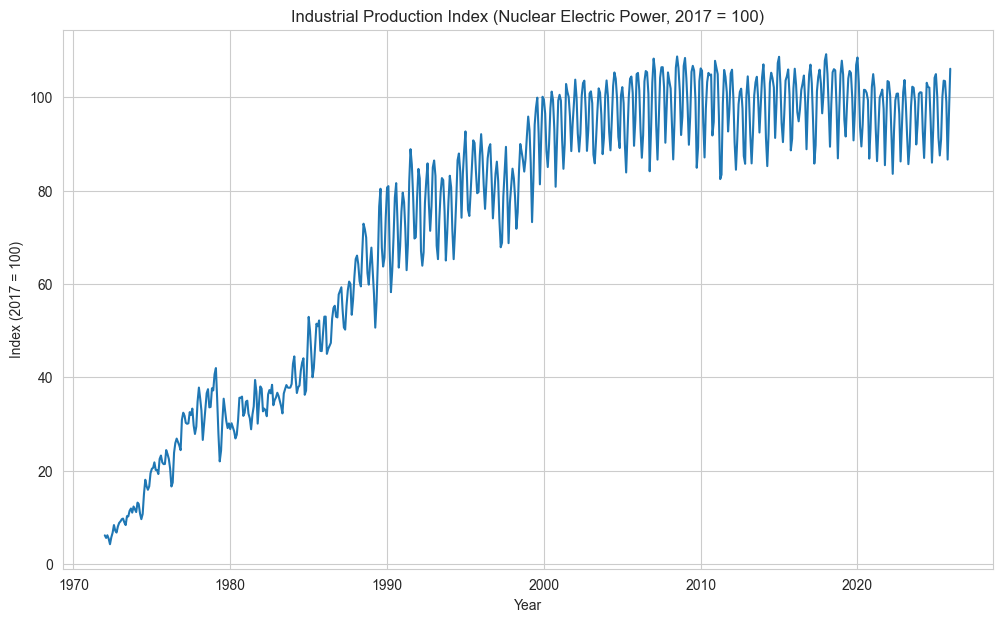

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(nuclearProduction.index, nuclearProduction['nuclear_generation'])

ax.set_title('Industrial Production Index (Nuclear Electric Power, 2017 = 100)')
ax.set_xlabel('Year')
ax.set_ylabel('Index (2017 = 100)')
plt.grid(True)
plt.show()

## Findings: Long-Term Trends in U.S. Nuclear Electricity Production

Figure 1 presents the Industrial Production Index for nuclear electric power generation (2017 = 100), illustrating the long-term trajectory of nuclear electricity production in the United States.

The series reveals two distinct structural phases. From the early 1970s through the late 1980s, nuclear electricity production expanded rapidly. This period reflects a sustained phase of reactor construction and capacity expansion, consistent with broader U.S. energy policy efforts to diversify energy sources and strengthen domestic electricity generation.

Beginning in the early 1990s, the series transitions into a plateau phase. Nuclear electricity production stabilizes at a relatively constant level, with the index fluctuating around a narrow range. This pattern indicates that the U.S. nuclear sector has experienced limited new capacity additions in recent decades, with production largely driven by the operation and maintenance of existing reactors rather than expansion.

In addition to these long-term patterns, the series exhibits pronounced seasonal variation, as shown by recurring fluctuations within each year. These cycles likely reflect operational factors such as scheduled maintenance, refueling outages, and seasonal electricity demand. Growth in nuclear electricity production slows markedly in the late 1980s, signaling the end of large-scale reactor expansion in the United States.

Taken together, these findings suggest a structural shift in the U.S. nuclear energy sector—from a period of rapid expansion to one of long-term stability. This transition has important implications for subsequent analysis, particularly in assessing how nuclear generation interacts with employment trends, industrial production, and broader energy-sector economic dynamics.

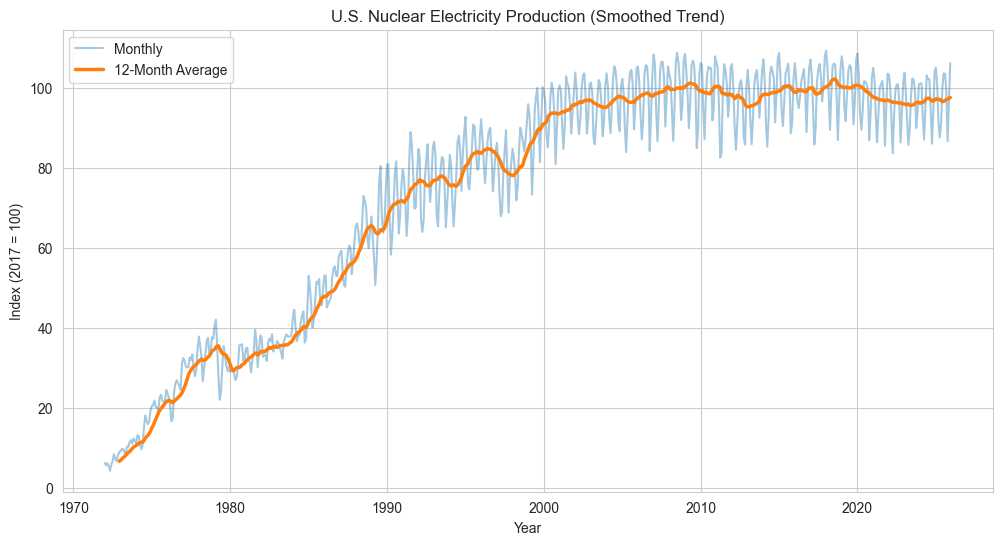

In [8]:
nuclearProduction['rolling_12'] = nuclearProduction['nuclear_generation'].rolling(12).mean()

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(nuclearProduction.index, nuclearProduction['nuclear_generation'], alpha=0.4, label='Monthly')
ax.plot(nuclearProduction.index, nuclearProduction['rolling_12'], linewidth=2.5, label='12-Month Average')

ax.set_title('U.S. Nuclear Electricity Production (Smoothed Trend)')
ax.set_xlabel('Year')
ax.set_ylabel('Index (2017 = 100)')
ax.legend()

plt.show()

### Smoothed Trend Interpretation

The 12-month rolling average highlights the underlying trend in nuclear electricity production by reducing short-term fluctuations. The smoothed series reinforces the transition from rapid growth in the late twentieth century to a stable production level in the 2000s, confirming that recent changes reflect cyclical variation rather than structural expansion.

## Limitations

This analysis focuses on nuclear electricity production as measured by an index and does not directly capture installed capacity, reactor counts, or regional variation. Additionally, the analysis is descriptive and does not establish causal relationships between nuclear generation and broader economic variables. Further analysis incorporating additional datasets is required to evaluate these relationships. 

## Data References and Citations List 

Board of Governors of the Federal Reserve System (US), Industrial Production: Utilities: Nuclear Electric Power Generation (NAICS = 221113) [IPN221113N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IPN221113N, March 18, 2026.